# 8.1.- El Bandido de 10 Brazos

En esta práctica vamos a implementar el clásico problema del **bandido de 10 brazos** descrito en la sección 2.3 del libro “Reinforcement Learning: An Introduction” de Sutton y Barto.

La idea es la siguiente:

- Imaginamos una máquina tragaperras con **10 palancas** (10 “brazos”).
- Cada brazo tiene una **recompensa media desconocida** para el agente.
- En cada paso de tiempo, el agente debe elegir **qué brazo tirar**.
- El objetivo es **maximizar la recompensa acumulada** a lo largo del tiempo.

Este problema es un entorno muy simple de aprendizaje por refuerzo, pero es perfecto para estudiar el dilema:

- **Explotar** el mejor brazo conocido hasta ahora.
- **Explorar** otros brazos, por si acaso alguno es todavía mejor.

En este notebook compararemos distintas estrategias **ε-Greedy**, viendo cómo cambia la recompensa media cuando variamos el parámetro ε.

In [3]:
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})
plt.rcParams["figure.figsize"] = (12, 5)

import seaborn as sns
sns.set(font_scale=1.3)

np.random.seed(33)

## Parámetros del experimento

Vamos a definir ahora los parámetros del problema del bandido de 10 brazos:

- `n_arms`: número de brazos de la máquina (en este caso, 10).
- `epsilons`: lista de valores de ε que queremos comparar:
  - `ε = 0`: estrategia puramente codiciosa (greedy), siempre elige el mejor brazo estimado.
  - `ε = 0.01`: rara vez explora, casi siempre explota.
  - `ε = 0.2`: explora con mucha más frecuencia.
- `n_steps`: número de pasos (tiradas) en cada partida.
- `n_plays`: número de partidas independientes que vamos a simular para cada valor de ε.  
  Esto nos permite hacer **promedios** y suavizar la aleatoriedad.

Además:

- Cada brazo tendrá una **recompensa verdadera** asociada, `Q_true`, muestreada de una distribución normal `N(μ, σ)`.
- En cada tirada, la recompensa observada será una muestra de `N(Q_true[brazo], σ)`.

Guardaremos todas las recompensas en un array `stored_data` para poder calcular después la **recompensa media** paso a paso.

In [7]:
# Parámetros del juego
n_arms = 10                     # número de brazos
epsilons = [0, 0.01, 0.2]       # diferentes valores de epsilon a comparar
n_steps = 1500                  # pasos (tiradas) por partida
n_plays = 2500                  # número de partidas independientes

# Array para almacenar los resultados:
# dimensiones: [n_epsilons, n_plays, n_steps]
stored_data = np.zeros((len(epsilons), n_plays, n_steps))

# Parámetros de las distribuciones de recompensa verdadera
mu = 0      # media de las recompensas verdaderas
sigma = 1   # desviación típica (tanto para Q_true como para las recompensas observadas)

print("Dimensión de stored_data:", stored_data.shape)

Dimensión de stored_data: (3, 2500, 1500)


## Estrategia ε-greedy y bucle de simulación

En este bloque implementamos el comportamiento del agente para cada valor de ε.

La lógica es sencilla:

- Cada partida tiene **10 brazos**, cada uno con una recompensa verdadera desconocida (`Q_true`).
- El agente mantiene una **estimación** de la recompensa de cada brazo (`Q_estimate`), que se actualiza según las recompensas recibidas.
- En cada paso:
  - **Explotación:** elige el brazo con mejor estimación actual.
  - **Exploración:** con probabilidad ε elige un brazo aleatorio.
- Tras cada tirada, registra la recompensa y actualiza la estimación del brazo utilizado.

Al finalizar, `stored_data` contendrá las recompensas obtenidas en cada paso para cada valor de ε, permitiendo comparar su rendimiento medio.

In [11]:
for epsilon_index, epsilon in enumerate(epsilons):
    print(f"Ejecutando simulaciones para epsilon = {epsilon}")
    
    for i in range(n_plays):
        # Reiniciar estimaciones para cada partida
        Q_sum = np.zeros(n_arms)    # suma acumulada de recompensas por brazo
        Q_pulls = np.ones(n_arms)   # número de tiradas por brazo (empezamos en 1 para evitar división por cero)
        Q_estimate = np.zeros(n_arms)
        
        # Definir las recompensas verdaderas de cada brazo en esta partida
        Q_true = np.random.normal(mu, sigma, n_arms)
        
        for j in range(n_steps):
            # 1) Explotación: escoger el brazo con mejor valor estimado
            arm = np.argmax(Q_estimate)
            reward = np.random.normal(Q_true[arm], sigma)
            
            # 2) Exploración: con probabilidad epsilon, elegir un brazo al azar
            if np.random.uniform(0.0, 1.0) < epsilon:
                arm = np.random.randint(0, n_arms)    # elegir brazo aleatorio
                reward = np.random.normal(Q_true[arm], sigma)
            
            # Guardar la recompensa obtenida en este paso
            stored_data[epsilon_index, i, j] = reward
            
            # 3) Actualizar las estimaciones Q
            Q_sum[arm] += reward
            Q_pulls[arm] += 1
            Q_estimate[arm] = Q_sum[arm] / Q_pulls[arm]

# Promedio sobre todas las partidas
results = np.mean(stored_data, axis=1)  # shape: [len(epsilons), n_steps]

print("Simulación terminada.")
print("Dimensión de results:", results.shape)

Ejecutando simulaciones para epsilon = 0
Ejecutando simulaciones para epsilon = 0.01
Ejecutando simulaciones para epsilon = 0.2
Simulación terminada.
Dimensión de results: (3, 1500)


## Visualización de la recompensa media

Una vez terminadas las simulaciones, `results` contiene:

- Una matriz de tamaño `[n_epsilons, n_steps]`.
- Cada fila corresponde a un valor de ε.
- Cada columna es la **recompensa media** en ese paso, promediada sobre las `n_plays` partidas.

Para analizar el comportamiento de las distintas estrategias ε-greedy:

- Dibujaremos en una misma gráfica la recompensa media por paso para:
  - `ε = 0` (política puramente codiciosa).
  - `ε = 0.01`.
  - `ε = 0.2`.

Esto nos permitirá ver:

- Cómo afecta la exploración al rendimiento a corto y largo plazo.
- Si una política que explora un poco puede superar a la política puramente codiciosa, que se puede atascar en un brazo subóptimo.

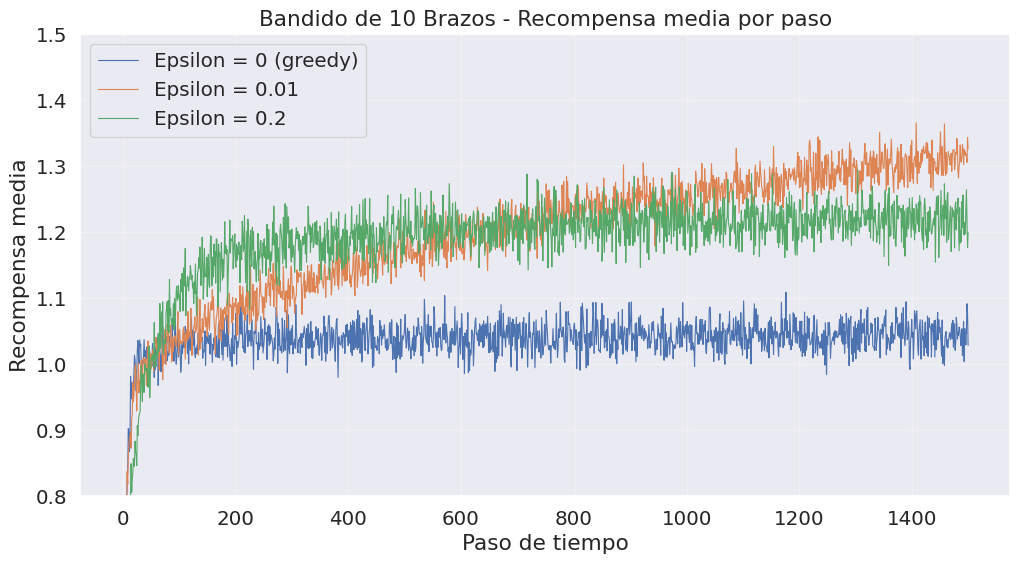

In [12]:
fig = plt.figure(figsize=(12, 6))
plt.title("Bandido de 10 Brazos - Recompensa media por paso")

# results tiene shape [len(epsilons), n_steps]
# Transponemos para que el eje x sea el paso
steps = np.arange(n_steps)

plt.plot(steps, results[0], lw=0.8, label="Epsilon = 0 (greedy)")
plt.plot(steps, results[1], lw=0.8, label="Epsilon = 0.01")
plt.plot(steps, results[2], lw=0.8, label="Epsilon = 0.2")

plt.xlabel("Paso de tiempo")
plt.ylabel("Recompensa media")
plt.legend()
plt.ylim([0.8, 1.5])
plt.grid(alpha=0.3)
plt.show()